In [8]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
fayl_nomi = 'Fifa analysis(AutoRecovered).xlsx'

In [10]:
df = pd.read_excel('Fifa analysis(AutoRecovered).xlsx', sheet_name='Data_FIFA')

In [11]:
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating,goal conversion rate
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,44.2,55.9,42.0,51.8,0,0,242,0,5.8,0.0
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,38.2,43.7,31.1,52.7,0,3,342,0,5.5,0.0
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,99.0,99.0,83.4,54.8,1,1,245,0,8.4,0.5
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,19.8,42.3,40.9,78.5,5,3,422,0,6.7,0.2
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,44.1,33.5,60.0,56.6,0,0,440,0,5.7,0.0


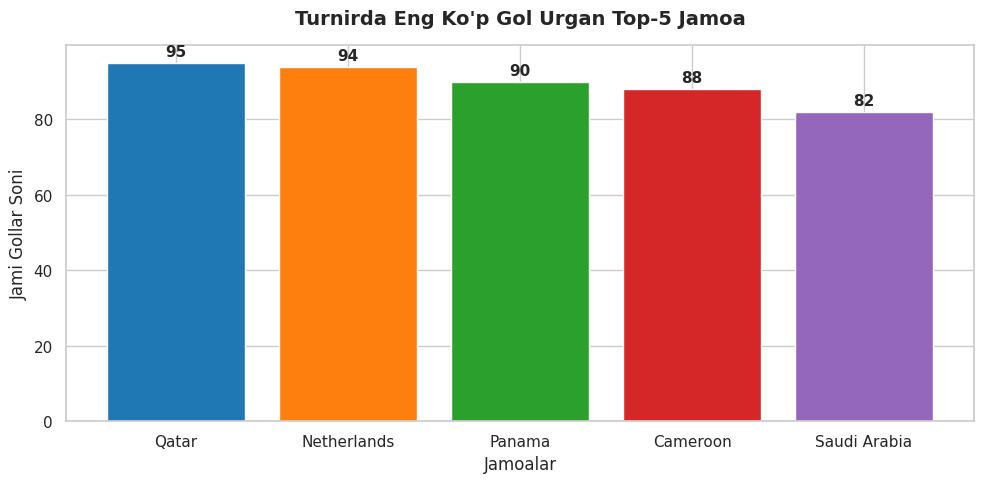

In [12]:
sns.set_theme(style="whitegrid")
top_teams_goals = df.groupby('team')['goals'].sum().reset_index()
top_teams_goals = top_teams_goals.sort_values(by='goals', ascending=False).head(5)
plt.figure(figsize=(10, 5))
bars = plt.bar(top_teams_goals['team'], top_teams_goals['goals'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.title("Turnirda Eng Ko'p Gol Urgan Top-5 Jamoa", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Jamoalar", fontsize=12)
plt.ylabel("Jami Gollar Soni", fontsize=12)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

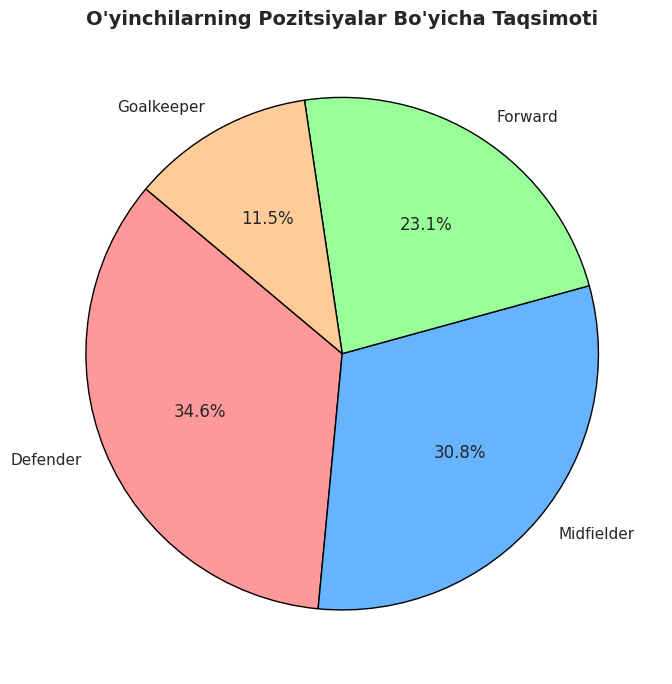

In [13]:
position_counts = df['position'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(position_counts,
        labels=position_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'],
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.title("O'yinchilarning Pozitsiyalar Bo'yicha Taqsimoti", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Defender (Himoyachilar): 34.6%

Midfielder (Yarim himoyachilar): 30.8%

Forward (Hujumchilar): 23.1%

Goalkeeper (Darvozabonlar): 11.5%

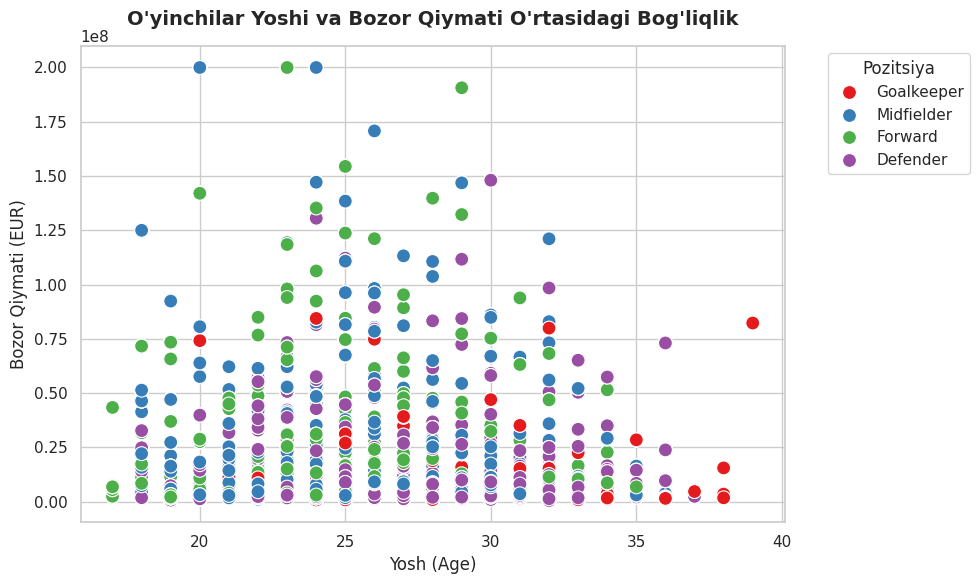

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='market_value_eur', hue='position', s=100, palette='Set1')
plt.title("O'yinchilar Yoshi va Bozor Qiymati O'rtasidagi Bog'liqlik", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Yosh (Age)", fontsize=12)
plt.ylabel("Bozor Qiymati (EUR)", fontsize=12)
plt.legend(title="Pozitsiya", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Pik (Eng yuqori qiymat) davri: O'yinchilarning eng yuqori bozor qiymati (150 mln – 200 mln EUR) asosan 20–28 yosh oralig'idagi futbolchilarga to'g'ri kelmoqda. Ayniqsa, Midfielder (ko'k) va Forward (yashil) pozitsiyasidagi o'yinchilar ushbu yoshda o'z faoliyatining eng yuqori narx cho'qqisiga erishgan.

Yosh omilining ta'siri: 30-32 yoshdan o'tgandan so'ng, futbolchilarning bozor qiymati keskin pasayish tendensiyasini ko'rsatmoqda (aksariyat nuqtalar 50 mln EUR dan pastga tushgan).

Pozitsiya xususiyati: Darvozabonlar (Goalkeeper - qizil) va Himoyachilar (Defender - binafsha) nisbatan barqaror, ammo o'rtacha narx segmentida tarqalgan.

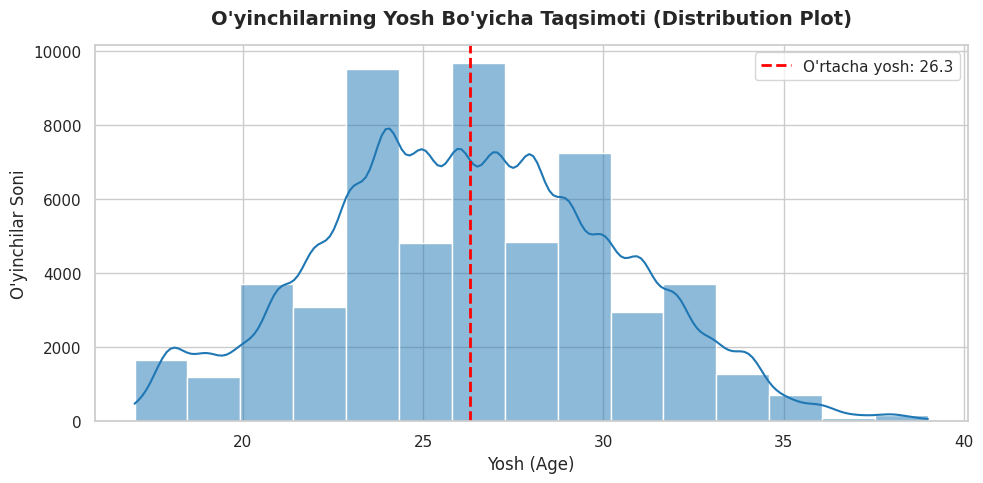

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], kde=True, color='#1f77b4', bins=15)
mean_age = df['age'].mean()
plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f"O'rtacha yosh: {mean_age:.1f}")
plt.title("O'yinchilarning Yosh Bo'yicha Taqsimoti (Distribution Plot)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Yosh (Age)", fontsize=12)
plt.ylabel("O'yinchilar Soni", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

O'rtacha yosh: Turnirdagi futbolchilarning o'rtacha yoshi 26.3 yoshni tashkil etmoqda, bu esa tarkiblarning optimal va tajribali ekanligidan dalolat beradi.

Asosiy qism: O'yinchilarning eng katta qismi 23–30 yosh oralig'ida to'plangan.

Taqsimot shakli: Taqsimot normal (simmetrik) ko'rinishga ega bo'lib, 18-20 yoshli juda yosh o'yinchilar hamda 35 yoshdan oshgan tajribali faxriy futbolchilar ulushi nisbatan kamroqni tashkil qiladi.